## Produces **Mosquito Predictions** for a specific region using MAMOTH ##

In [1]:
import pandas as pd
import datetime
import math
import numpy as np
import missingno
import json
from statistics import mean
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import sys

sys.path.insert(0, "../../../Mamoth Modules")
sys.path.insert(0, "../../../Modules")

from preprocessing_utils import *

from Preprocessing_Module import read_data, select_columns, reshape_dataset
from Initializer_Module import initializer
from Neural_Network_Module import Dataset, transformations, FeedforwardNeuralNetModel, train_nn, give_predictions
from Model_Validation_Module import validation_plots, metrics

enc = 'utf-8'
dec = 'greek8'

pd.options.display.max_columns = None
pd.options.display.max_rows = 10

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
NUTS0 = 'GR'
NUTS2 = 'Thessaly'
NUTS2_EL = 'θεσσαλιας'

In [4]:
YEAR = 2023
MONTH = 'August'
PERIOD = '1st'

In [5]:
dataset = pd.read_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Timeline_{YEAR}-{MONTH}-{PERIOD}_filled.csv', encoding=enc)


In [6]:
dataset.head()

,lau1,region,x,y,dt_placement,year,month,indices_image_date,indices_lat,indices_lon,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,monthly_lst_lat,monthly_lst_lon,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,indices_image_date.1,indices_lat.1,indices_lon.1,acc_rainfall_jan,dt_placement_minus_7,dt_placement_minus_14,dt_placement_minus_7_avail,dt_placement_minus_14_avail,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.635299,0.370492,0.034333,-0.427839,-0.034333,0.219168,-0.082988,-0.316662,0.082988,0.079135,0.061730,0.046492,0.061730,NaN,NaN,39.662866,22.635299,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,2023-07-31,39.650181,22.650104,172.699636,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-08-01,2023,8,2023-08-01,39.752697,22.707165,0.354209,0.291871,-0.246103,-0.291871,0.477410,0.303657,-0.365873,-0.303657,0.142033,0.051151,0.134520,0.051151,NaN,NaN,39.752697,22.707165,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-08-01,2023,8,2023-08-01,39.788630,22.729622,0.515865,0.083989,-0.498988,-0.083989,0.424160,0.213616,-0.367591,-0.213616,0.098599,0.044688,0.087157,0.044688,NaN,NaN,39.788630,22.729622,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-08-01,2023,8,2023-08-01,39.662866,22.779030,0.588635,0.235191,-0.518020,-0.235191,0.440729,0.111367,-0.408259,-0.111367,0.083341,0.058407,0.089037,0.058407,NaN,NaN,39.662866,22.779030,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,2023-07-31,39.650181,22.750104,162.692826,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-08-01,2023,8,2023-08-01,39.698798,22.779030,0.538953,0.143744,-0.491663,-0.143744,0.519645,0.124894,-0.488033,-0.124894,0.054584,0.044943,0.037090,0.044943,NaN,NaN,39.698798,22.779030,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,2023-07-31,39.750182,22.750104,238.974574,2023-07-25,2023-07-18,2023-07-25,2023-07-18,0.0,0.0


In [7]:
dataset.rename(columns={"region": "nuts2"}, inplace=True)

In [8]:
dataset = dataset.rename(columns=lambda x: re.sub('_new', '', x))

In [9]:
dataset.drop(columns=['indices_image_date', 'indices_lat', 'indices_lon' , 'lst_image_date', 'lst_lat','lst_lon' ,'monthly_lst_lat', 'monthly_lst_lon', 
                         'indices_image_date.1', 'indices_lat.1', 'indices_lon.1', 'dt_placement_minus_7', 'dt_placement_minus_14', 'dt_placement_minus_7_avail',
                         'dt_placement_minus_14_avail'], inplace = True)

KeyError: "['lst_image_date', 'lst_lat', 'lst_lon'] not found in axis"

In [10]:
dataset.head(5)

,lau1,nuts2,x,y,dt_placement,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,αγιας,θεσσαλιας,22.63715,39.66477,2023-07-16,2023,7,0.251246,-0.099552,-0.317585,0.099552,0.176491,-0.141905,-0.269345,0.141905,0.038550,0.026596,0.021694,0.026596,15908.0,14846.0,14219.000000,13818.000000,14307.062500,13704.263158,14637.352941,13943.333333,14850.466667,14041.625000,172.699636,0.0,0.0
1,αγιας,θεσσαλιας,22.70702,39.75460,2023-07-16,2023,7,0.662888,0.297193,-0.543105,-0.297193,0.680870,0.325287,-0.545395,-0.325287,0.051331,0.048841,0.043247,0.048841,15056.0,14584.0,14223.600000,13741.846154,14084.133333,13737.714286,14400.923077,13793.692308,14395.000000,13897.142857,238.974574,0.0,0.0
2,αγιας,θεσσαλιας,22.73031,39.79054,2023-07-16,2023,7,0.602816,0.167256,-0.539287,-0.167256,0.683428,0.266674,-0.590612,-0.266674,0.081512,0.077846,0.057756,0.077846,15067.0,14471.0,14031.307692,13745.444444,13840.846154,13747.428571,14317.428571,13781.400000,14333.600000,13838.888889,238.974574,0.0,0.0
3,αγιας,θεσσαλιας,22.77688,39.66477,2023-07-16,2023,7,0.674726,0.248577,-0.581351,-0.248577,0.539212,0.099183,-0.502274,-0.099183,0.062127,0.060720,0.035462,0.060720,15531.0,14799.0,14166.800000,13831.857143,14232.187500,13729.571429,14586.642857,13952.500000,14702.571429,14088.285714,162.692826,0.0,0.0
4,αγιας,θεσσαλιας,22.77688,39.70070,2023-07-16,2023,7,0.492114,0.087982,-0.460252,-0.087982,0.514643,0.101370,-0.477144,-0.101370,0.041024,0.031277,0.029850,0.031277,15537.0,14897.0,14235.545455,13809.769231,14269.294118,13762.076923,14640.357143,13945.142857,14705.153846,14098.000000,238.974574,0.0,0.0


In [11]:
grouped = dataset.groupby(['dt_placement', 'lau1', 'nuts2'], as_index = False)
dataset = grouped.mean()
dataset

,dt_placement,lau1,nuts2,x,y,year,month,ndvi,ndmi,ndwi,ndbi,ndvi_mean,ndmi_mean,ndwi_mean,ndbi_mean,ndvi_std,ndmi_std,ndwi_std,ndbi_std,lst_day,lst_night,lst_jan_day_mean,lst_jan_night_mean,lst_feb_day_mean,lst_feb_night_mean,lst_mar_day_mean,lst_mar_night_mean,lst_apr_day_mean,lst_apr_night_mean,acc_rainfall_jan,acc_rainfall_1week,acc_rainfall_2week
0,2023-07-16,αγιας,θεσσαλιας,22.750267,39.710970,2023.0,7.0,0.603369,0.188831,-0.535154,-0.188831,0.598568,0.188761,-0.533408,-0.188761,0.045108,0.039909,0.032660,0.039909,15294.285714,14716.571429,14158.229570,13810.607919,14132.381348,13770.111663,14483.438175,13900.012383,14528.540407,14007.143707,211.711384,0.0,0.000000
1,2023-07-16,αλμυρου,θεσσαλιας,22.692366,39.136391,2023.0,7.0,0.451252,0.187379,-0.372398,-0.187379,0.428335,0.140504,-0.367891,-0.140504,0.084486,0.067249,0.076023,0.067249,15554.555556,14719.555556,14236.213555,13871.070700,14235.830525,13815.772792,14503.039805,14000.498550,14640.452078,14072.106614,314.133211,0.0,0.000000
2,2023-07-16,αλοννησου,θεσσαλιας,24.073790,39.328960,2023.0,7.0,0.401898,0.027597,-0.368799,-0.027597,0.408986,0.032804,-0.366971,-0.032804,0.022333,0.031616,0.012981,0.031616,15394.000000,14892.000000,14303.111111,14120.666667,14247.800000,14074.285714,14424.133333,14144.066667,14543.000000,14215.666667,204.246283,0.0,0.000000
3,2023-07-16,αργιθεας,θεσσαλιας,21.430513,39.221380,2023.0,7.0,0.489877,0.315404,-0.371607,-0.315404,0.504079,0.304001,-0.385539,-0.304001,0.059954,0.057933,0.043279,0.057933,15078.000000,14650.000000,13984.796537,13767.640659,13972.290278,13581.276389,14264.541026,13850.111111,14318.077381,13868.033333,201.881806,0.0,0.401304
4,2023-07-16,βολου,θεσσαλιας,22.883800,39.351977,2023.0,7.0,0.398046,0.090409,-0.351035,-0.090409,0.373683,0.116457,-0.319458,-0.116457,0.054643,0.068233,0.066372,0.068233,15735.333333,14862.000000,14310.624820,13874.456288,14320.436508,13834.927778,14589.631410,13978.820513,14708.583333,14067.142857,208.555492,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20,2023-07-16,τεμπων,θεσσαλιας,22.553160,39.852112,2023.0,7.0,0.528302,0.165301,-0.455988,-0.165301,0.492514,0.169623,-0.414469,-0.169623,0.037114,0.043803,0.023962,0.043803,15309.600000,14745.200000,14131.844872,13769.820000,14115.170075,13710.264791,14425.669118,13892.648535,14496.147902,13987.089286,155.597145,0.0,0.000000
21,2023-07-16,τρικκαιων,θεσσαλιας,21.797560,39.635058,2023.0,7.0,0.497658,0.096635,-0.448860,-0.096635,0.463186,0.090174,-0.414439,-0.090174,0.057455,0.067236,0.044242,0.067236,15537.000000,14928.800000,14191.183077,13785.802381,14353.424316,13765.126176,14621.389846,13986.928283,14689.561490,14047.238095,296.693971,0.0,1.295069
22,2023-07-16,τυρναβου,θεσσαλιας,22.343000,39.828472,2023.0,7.0,0.495238,0.086986,-0.458087,-0.086986,0.457442,0.080923,-0.420964,-0.080923,0.042919,0.047136,0.025760,0.047136,15563.250000,14792.500000,14205.631944,13756.379121,14250.387054,13720.940664,14569.709428,13922.793269,14687.921314,14042.280258,124.964158,0.0,0.579493
23,2023-07-16,φαρκαδονας,θεσσαλιας,22.020557,39.603750,2023.0,7.0,0.402674,0.061688,-0.369027,-0.061688,0.374602,0.104884,-0.332565,-0.104884,0.023651,0.022693,0.021053,0.022693,15572.333333,14795.000000,14179.025000,13814.481685,14325.770833,13813.812500,14609.167725,14019.155400,14719.909041,14095.839286,233.073064,0.0,0.144412


In [12]:
dataset['dt_placement'] = pd.to_datetime(dataset['dt_placement'])

In [13]:
dataset['day'] = dataset['dt_placement'].apply(lambda x : x.day)
dataset['week'] = dataset.apply(lambda row: datetime.date(int(row['year']), int(row['month']), int(row['day'])).isocalendar().week, axis=1)

In [14]:
dataset = encode_cyclical(dataset, 'day', 31)
dataset = encode_cyclical(dataset, 'month', 12)
dataset = encode_cyclical(dataset, 'week', 53)

In [15]:
mosquito_data = read_data(f'../../data/{NUTS0}_MSQ_culex_2011-2022_processed.csv')

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')


In [16]:
mosquito_data.nuts2.unique()

array(['CENTRAL MACEDONIA', 'THESSALY', 'CRETE', 'WESTERN GREECE'],
      dtype=object)

In [17]:
mosquito_data_nuts2 = mosquito_data.query("nuts2 == 'THESSALY'").copy()
mosquito_data_nuts2.reset_index(inplace = True, drop = True)

In [18]:
mosq_columns = mosquito_data_nuts2.columns
mosq_columns

Index(['nuts2', 'x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
       'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
       'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
       'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
       'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
       'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
       'acc_rainfall_jan', 'sp_cnt_1km', 'biol_cnt_1km', 'wc_l_1km',
       'pg_area_1km', 'fs_area_1km', 'wc_mean_dist_1000',
       'coast_mean_dist_1000', 'dem_mean_1km', 'slope_mean_1km',
       'aspect_mean_1km', 'waw_mean_1km', 'flow_accu_1km', 'mosq_now'],
      dtype='object')

In [19]:
columns_to_keep = ['x', 'y', 'dt_placement', 'day', 'month', 'week', 'year',
                'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean',
                'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 'lst_day',
                'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean',
                'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week',
                'acc_rainfall_jan', 'mosq_now']

mosquito_data_nuts2 = select_columns(mosquito_data_nuts2, columns_to_keep, columns_to_keep)

mosquito_data_nuts2 = reshape_dataset(mosquito_data_nuts2,['x','y','dt_placement'])

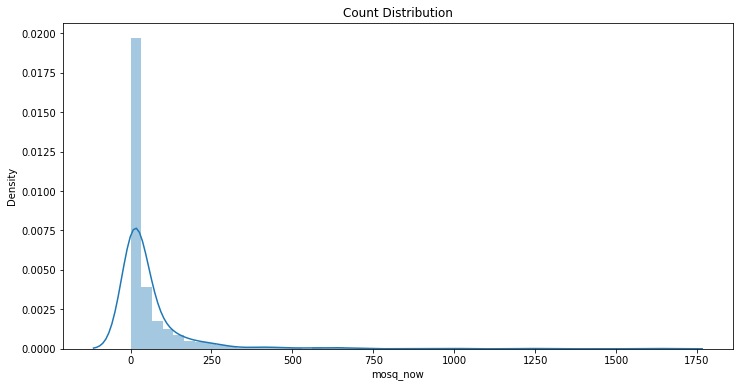

In [20]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

In [21]:
#quantile might change based on sns plots
mosq_quantilie = mosquito_data_nuts2['mosq_now'].quantile(0.90)

mosquito_data_nuts2['mosq_now'][mosquito_data_nuts2['mosq_now'] > mosq_quantilie] = mosq_quantilie+1

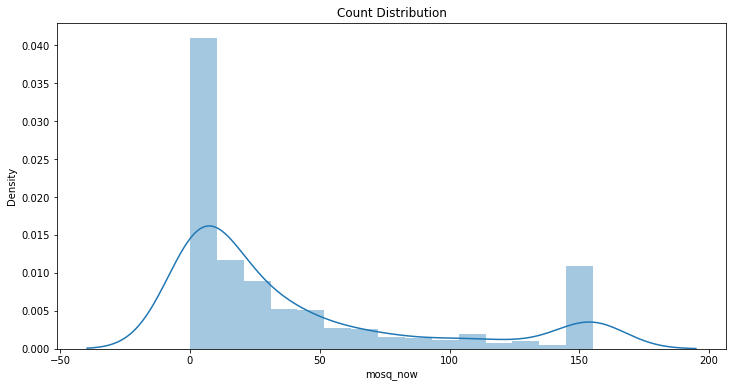

In [22]:
plt.figure(figsize=(12,6))
sns.distplot(mosquito_data_nuts2['mosq_now'])
plt.title('Count Distribution')
plt.show()

<AxesSubplot:>

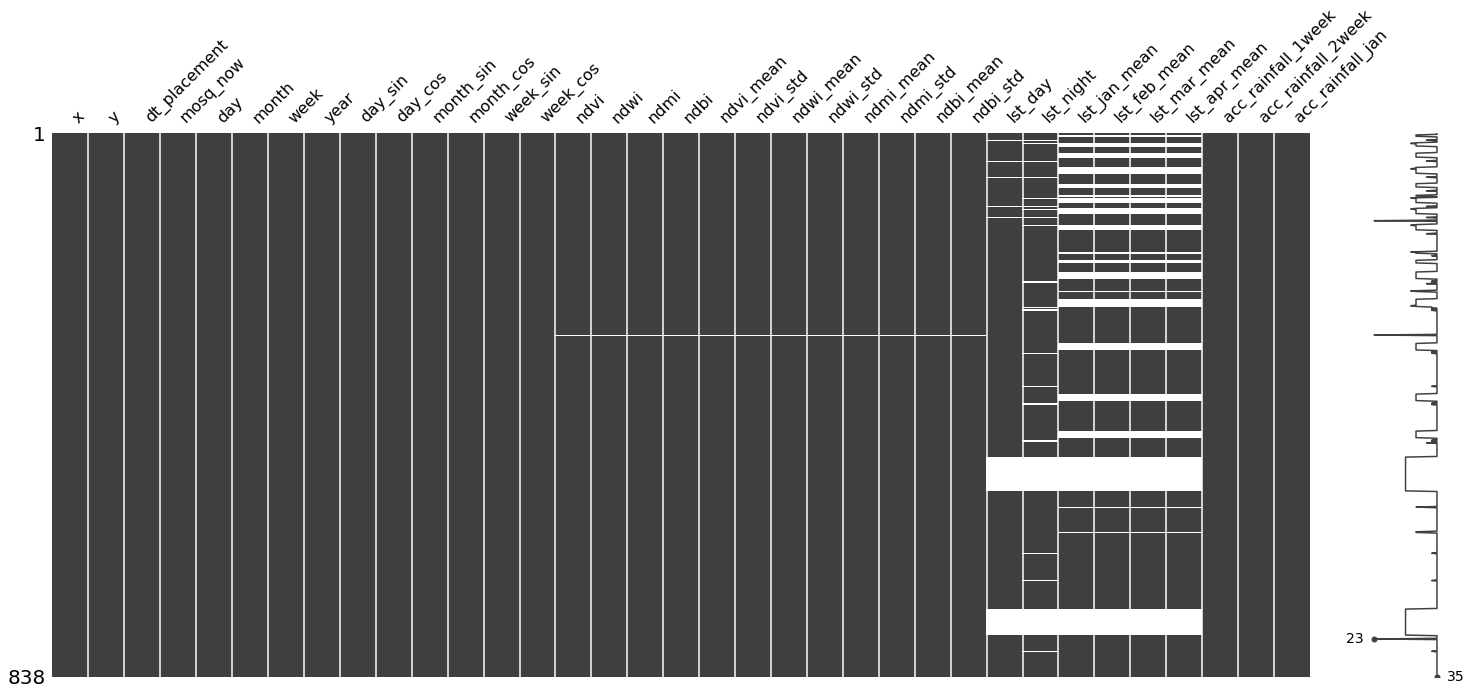

In [23]:
missingno.matrix(mosquito_data_nuts2)

In [24]:
imputer = KNNImputer()

features_for_impute = ['x', 'y', 'day', 'month', 'week', 'year', 'day_sin', 'day_cos', 'month_sin', 'month_cos', 'week_sin', 'week_cos',
                        'ndvi', 'ndwi', 'ndmi', 'ndbi', 'ndvi_mean', 'ndvi_std', 'ndwi_mean', 'ndwi_std', 'ndmi_mean', 'ndmi_std', 'ndbi_mean', 'ndbi_std', 
                        'lst_day', 'lst_night', 'lst_jan_mean', 'lst_feb_mean', 'lst_mar_mean', 'lst_apr_mean', 'acc_rainfall_1week', 'acc_rainfall_2week', 'acc_rainfall_jan']

mosquito_data_sub = mosquito_data_nuts2[features_for_impute]

imputed_data = pd.DataFrame(imputer.fit_transform(mosquito_data_sub), columns = mosquito_data_sub.columns)

In [25]:
imputed_columns = ['ndvi','ndmi', 'ndwi', 'ndbi','ndvi_mean','ndmi_mean','ndwi_mean','ndbi_mean','ndvi_std', 'ndmi_std','ndwi_std','ndbi_std',
                   'lst_day','lst_night','lst_jan_mean','lst_feb_mean','lst_mar_mean','lst_apr_mean']

mosquito_data_nuts2[imputed_columns] = imputed_data[imputed_columns]

<AxesSubplot:>

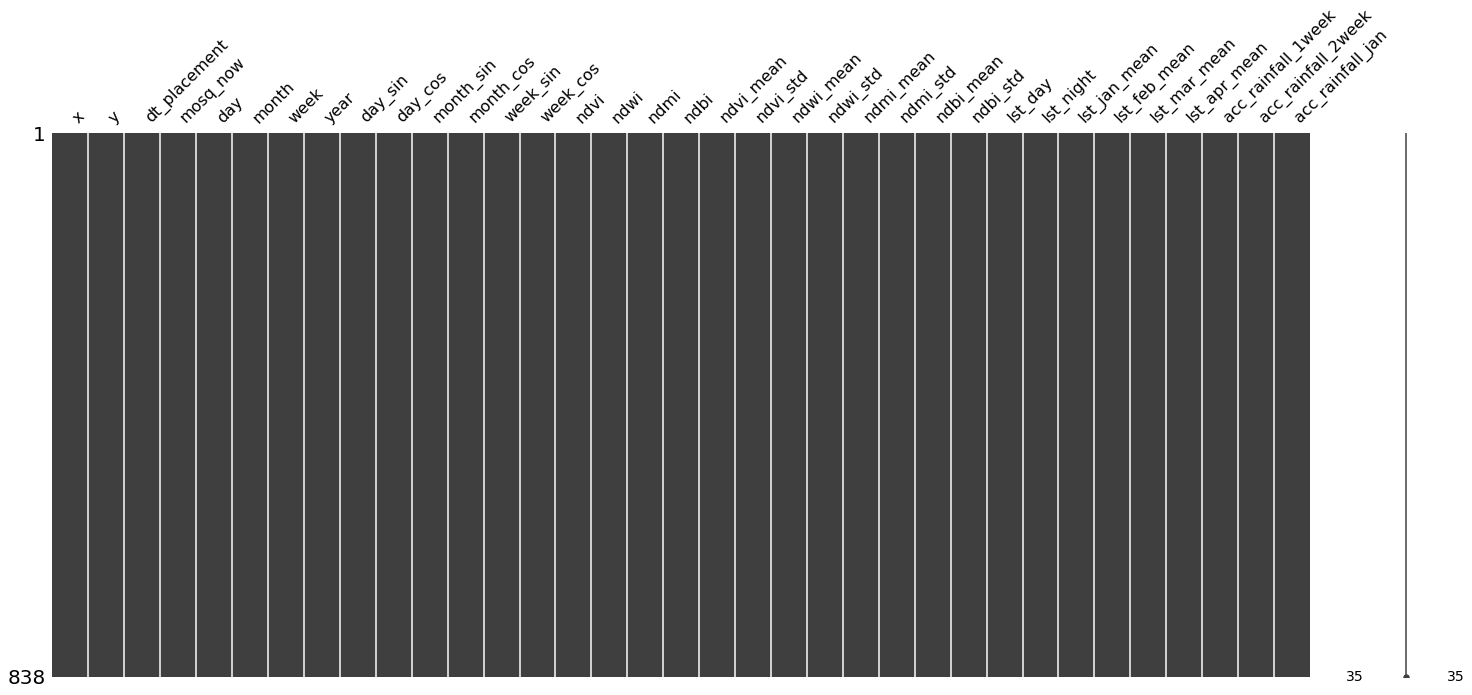

In [26]:
missingno.matrix(mosquito_data_nuts2)

In [27]:
step = 15
only_env = True
case_title = 'NN mosq regression'
exp = False
date_col = 'dt_placement'
model_type = 'mosquito_regression'
transform_target = True
augment = True

In [28]:
mosquito_data_nuts2 = initializer(mosquito_data_nuts2,2,10,25,step,[date_col], env=only_env, date_column = date_col, mosq_column='mosq_now')

Bounds: [  0.   16.5 155.3]


In [29]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.25, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

model = FeedforwardNeuralNetModel(num_features=len(train_X[0]), num_class=1, hidden_layers = [264,128,128,64], dropout=0.2, model_type=model_type, transform = transform_target)

Epoch 001: | Train Loss: 41.17145 | Val Loss: 29.03556 | Train Acc: 4.272| Val Acc: 3.444
Epoch 002: | Train Loss: 37.04453 | Val Loss: 27.76850 | Train Acc: 3.622| Val Acc: 3.224
Epoch 003: | Train Loss: 34.85396 | Val Loss: 26.12731 | Train Acc: 3.153| Val Acc: 2.829
Epoch 004: | Train Loss: 34.00458 | Val Loss: 25.70992 | Train Acc: 2.944| Val Acc: 2.572
Epoch 005: | Train Loss: 33.27407 | Val Loss: 24.13539 | Train Acc: 2.754| Val Acc: 2.332
Epoch 006: | Train Loss: 33.03988 | Val Loss: 23.49964 | Train Acc: 2.755| Val Acc: 2.068
Epoch 007: | Train Loss: 32.77448 | Val Loss: 23.68617 | Train Acc: 2.679| Val Acc: 2.175
Epoch 008: | Train Loss: 32.92604 | Val Loss: 24.34949 | Train Acc: 2.698| Val Acc: 2.179
Epoch 009: | Train Loss: 32.38022 | Val Loss: 24.08650 | Train Acc: 2.622| Val Acc: 1.978
Epoch 010: | Train Loss: 32.24562 | Val Loss: 23.69838 | Train Acc: 2.625| Val Acc: 1.951
Epoch 011: | Train Loss: 32.28979 | Val Loss: 23.70011 | Train Acc: 2.640| Val Acc: 1.942
Epoch 012:

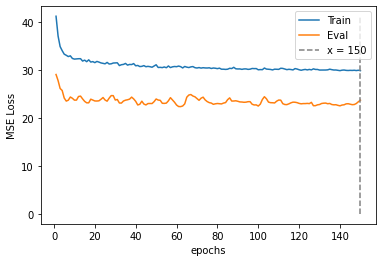

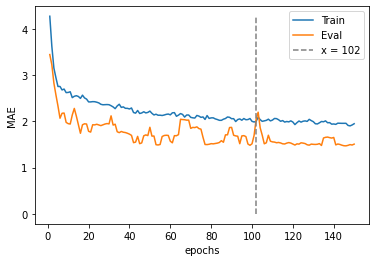

In [30]:
train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [31]:
metrics(train, test, threshold=30)

MAE on train set:  19.315171766621773
min prediction: 1
max prediction: 187

MAE on test set:  25.325954434222083
Error ⩽ 30: 71.76 %
min prediction: 1
max prediction: 198


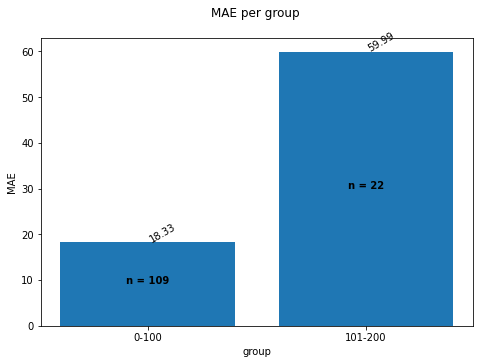

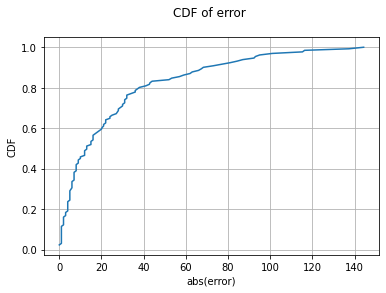

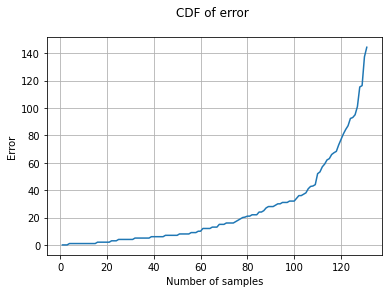

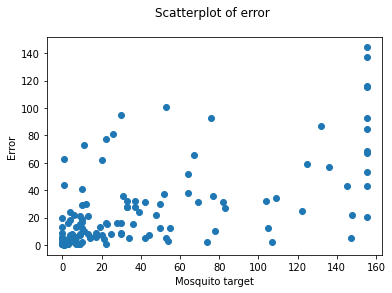

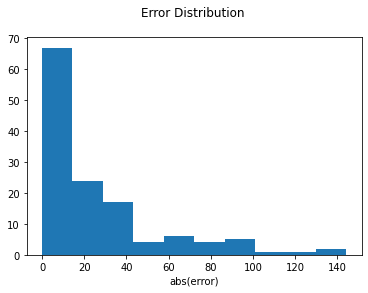

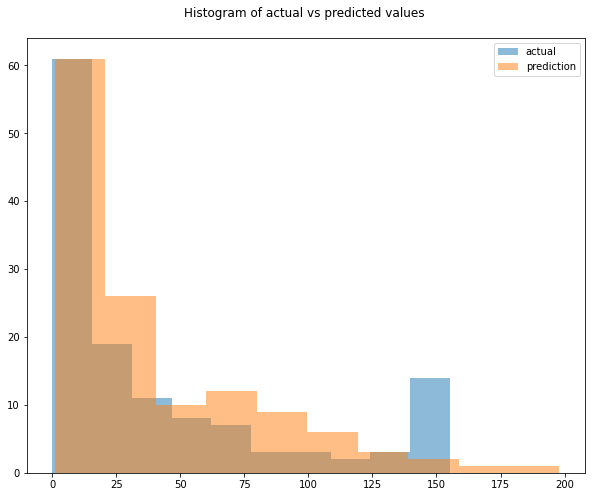

In [32]:
validation_plots(test,model_type)

Epoch 001: | Train Loss: 34.11827 | Val Loss: 0.01230 | Train Acc: 2.462| Val Acc: 0.045
Epoch 002: | Train Loss: 33.22227 | Val Loss: 0.00899 | Train Acc: 2.300| Val Acc: 0.045
Epoch 003: | Train Loss: 33.10180 | Val Loss: 0.03268 | Train Acc: 2.332| Val Acc: 0.045
Epoch 004: | Train Loss: 32.78488 | Val Loss: 0.06842 | Train Acc: 2.220| Val Acc: 0.045
Epoch 005: | Train Loss: 32.59254 | Val Loss: 0.04584 | Train Acc: 2.204| Val Acc: 0.045
Epoch 006: | Train Loss: 32.61556 | Val Loss: 0.10274 | Train Acc: 2.240| Val Acc: 0.045
Epoch 007: | Train Loss: 32.61628 | Val Loss: 0.18846 | Train Acc: 2.225| Val Acc: 0.045
Epoch 008: | Train Loss: 32.63383 | Val Loss: 0.30589 | Train Acc: 2.240| Val Acc: 1.045
Epoch 009: | Train Loss: 32.35111 | Val Loss: 0.06691 | Train Acc: 2.166| Val Acc: 0.045
Epoch 010: | Train Loss: 32.66730 | Val Loss: 0.19670 | Train Acc: 2.237| Val Acc: 0.045
Epoch 011: | Train Loss: 32.45459 | Val Loss: 0.05558 | Train Acc: 2.207| Val Acc: 0.045
Epoch 012: | Train Lo

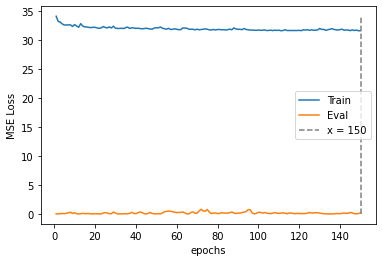

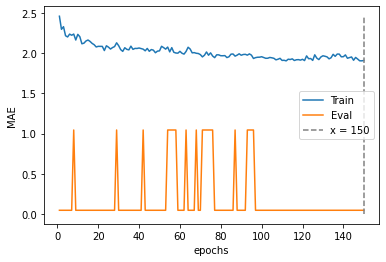

In [33]:
train_X, train_y, test_X, test_y, scaler = transformations(mosquito_data_nuts2, model_type = model_type, split = 0.000001, augment=augment)

training_set = Dataset(train_X, train_y, model_type=model_type, transform = transform_target)
testing_set = Dataset(test_X, test_y, model_type=model_type, transform = transform_target)

train, test, model = train_nn(model = model, learning_rate = 0.005, epochs = 150, batch_size = 128, train_set = training_set, test_set = testing_set, early_stop = False)

In [34]:
dataset_mamoth = dataset_mamoth_preparation(dataset, columns_to_keep)

In [35]:
mosqutio_predictions = dataset_mamoth[['x', 'y', 'dt_placement']].copy()

In [36]:
dataset_mamoth.drop(columns=['dt_placement'], inplace=True)

In [37]:
dataset_mamoth_sub = dataset_mamoth[features_for_impute]

In [38]:
mamoth_imputed = pd.DataFrame(imputer.transform(dataset_mamoth_sub), columns = dataset_mamoth_sub.columns)

In [39]:
dataset_mamoth[features_for_impute] = mamoth_imputed[features_for_impute]

<AxesSubplot:>

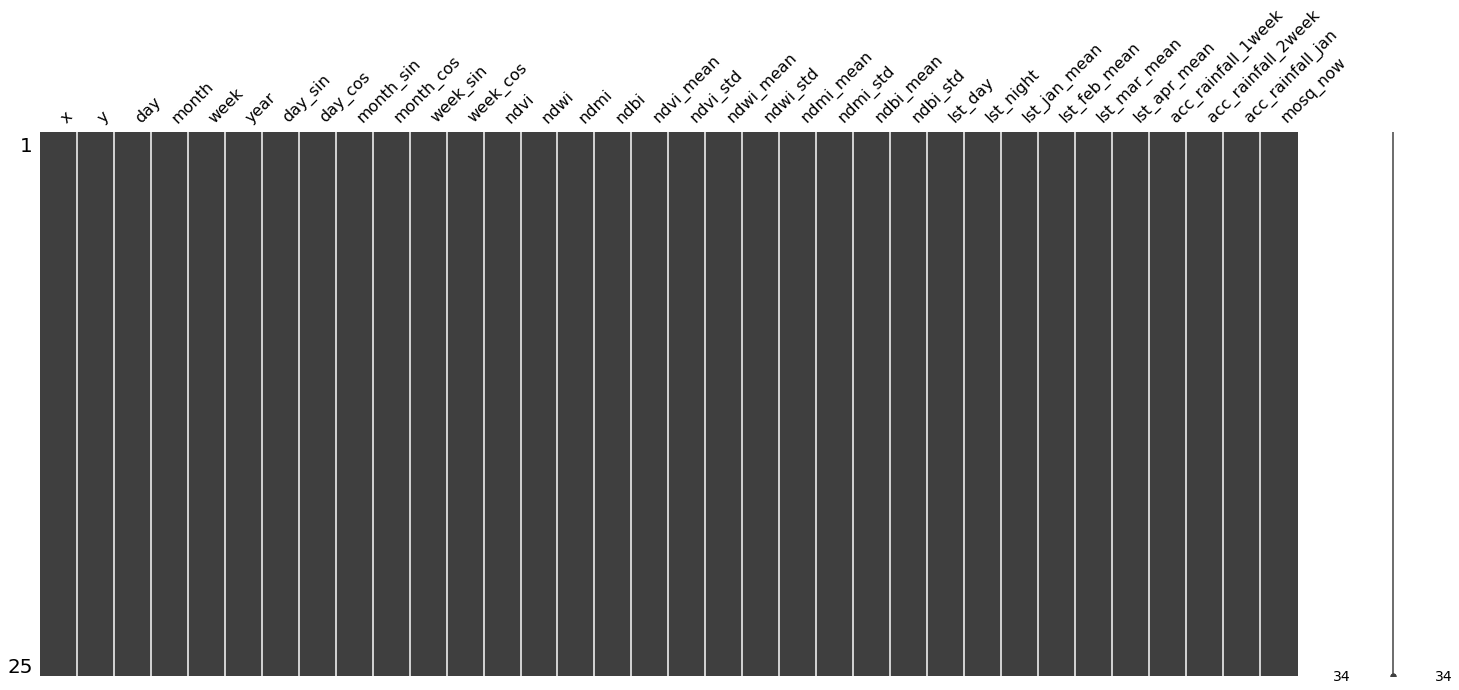

In [40]:
missingno.matrix(dataset_mamoth)

In [41]:
dataset_mamoth_X, dataset_mamoth_y = dataset_mamoth.iloc[:,:-1], dataset_mamoth.iloc[:,-1]

dataset_mamoth_X = scaler.transform(dataset_mamoth_X)

In [42]:
dataset_mamoth = Dataset(dataset_mamoth_X, dataset_mamoth_y, model_type=model_type, transform = transform_target)

In [43]:
predictions = give_predictions(model, dataset_mamoth)

In [44]:
mosqutio_predictions['mosq_pred'] = predictions

In [45]:
mosqutio_predictions

,x,y,dt_placement,mosq_pred
0,22.750267,39.710970,2023-07-16,69
1,22.692366,39.136391,2023-07-16,39
2,24.073790,39.328960,2023-07-16,1
3,21.430513,39.221380,2023-07-16,48
4,22.883800,39.351977,2023-07-16,58
...,...,...,...,...
20,22.553160,39.852112,2023-07-16,115
21,21.797560,39.635058,2023-07-16,92
22,22.343000,39.828472,2023-07-16,130
23,22.020557,39.603750,2023-07-16,77


In [46]:
mosqutio_predictions.to_csv(f'../../data/{NUTS2}/{NUTS0}_{NUTS2}_Culex_Predictions_{YEAR}-{MONTH}-{PERIOD}.csv', index = False)